# 分类分数与参数更新

猫和狗的照片由颜色数值组成，标签说明各自所属类别。颜色、位置和标签在下面的代码中都有对应的数据。

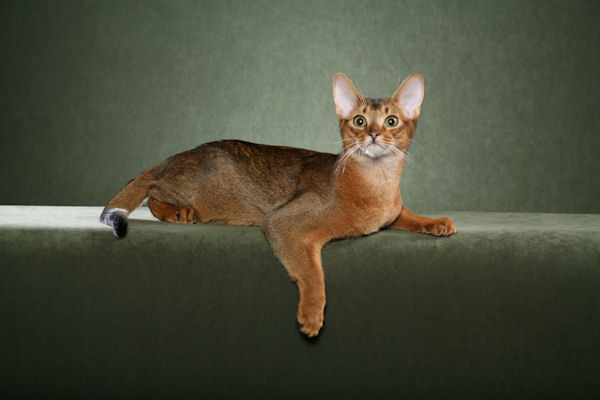

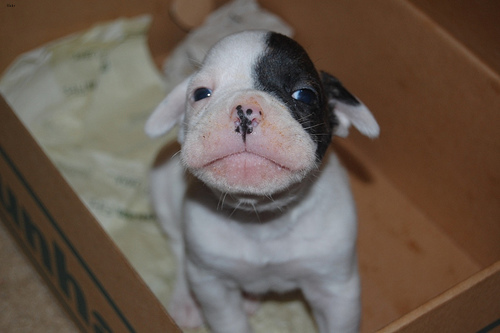

照片与标注：Oxford-IIIT Pet，Parkhi、Vedaldi、Zisserman、Jawahar，CVPR 2012。

在 Kaggle 点击 **Copy & Edit** 建立自己的副本，第一次从上到下运行。开头的准备格提供照片、变量和显示函数；后面的知识点分格操作。只修改当前格的参数时重跑当前格；修改前文创建的图片、标签或模型时，重跑使用它的后续格。报错后查看红字末行和标出的代码行，修正后重跑该格。**Save Version → Save & Run All** 会按顺序完整执行并保存输出。图片已随文件提供，无需联网下载。

运行下面一格后，照片会直接显示。样本编码已折叠，后面的代码按知识点分别运行；每处的注释指出可以改动的数值。

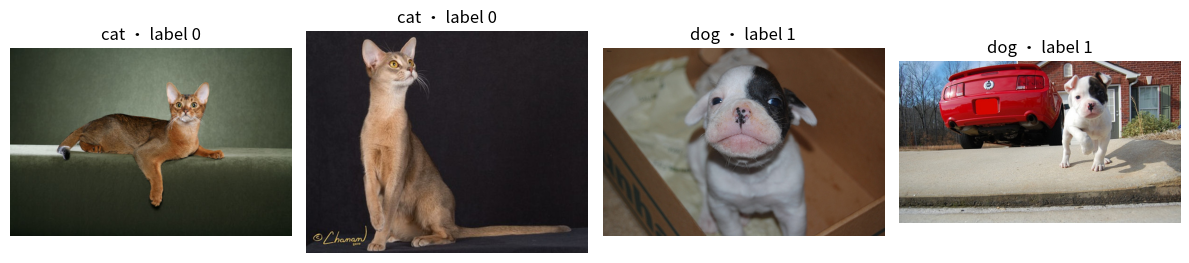

真实照片；标签顺序： [0, 0, 1, 1]


In [1]:
from pathlib import Path
from copy import deepcopy
import base64, json, csv, io
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

torch.manual_seed(7)  # 让教学算例使用相同随机起点
torch.set_num_threads(2)  # 小练习只使用少量 CPU 线程
if any(f.name == 'Microsoft YaHei' for f in font_manager.fontManager.ttflist):
    plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False
WORK = Path('/kaggle/working') if Path('/kaggle/working').is_absolute() and Path('/kaggle/working').exists() else Path('knowledge_outputs')
WORK.mkdir(parents=True, exist_ok=True)
ASSETS = WORK / 'lesson_assets'
ASSETS.mkdir(exist_ok=True)

BUNDLED = {'pets/Abyssinian_1.jpg': '...', 'pets/Abyssinian_2.jpg': '...', 'pets/american_bulldog_2.jpg': '...', 'pets/american_bulldog_3.jpg': '...', 'pets/Abyssinian_1.png': 'iVBORw0KGgoAAAANSUhEUgAAAlgAAAGQCAAAAABXXkFEAAAAB3RJTUUH2wMaCxY6GugI4wAAC2ZJREFUeJzt3dF6ozYURWHw9P0f2e6FJxMbJCEJbekcaf03befr2PiwIohNyP7YgPboChKEBQnCggRhQYKwIEFYkCAsSBAWJAgLEoQFCcKCBGFBgrAgQViQICxIEBYkCAsShAUJwoIEYUGCsCBBWJAgLEgQFiQICxKEBQnCggRhQYKwIEFYkCAsSBAWJAgLEoQFCcKCBGFBgrAgQViQICxIEBYkCAsShAUJwoIEYUGCsCBBWJAgLEgQFiQICxKEBQnCggRhQYKwIEFYkCAsSBAWJAgLEoQFCcKCBGFBgrAgQViQICxIEBYkCAsS/43egLnsv//6GrcVFhBWO/vxv1Zui0NhM3vGn6yDsFoJVbRwWYTVSLihdcviHEtrv3mi9S7T4cnazpLVRGJpqq3i+yG9tUVYTSQPeTVNnB/QWVl0pVdxohX4K85O1wjLomBEvsoirBYu9nlpEr4SCiOsHspKmaErwuqjpJXo/+sqOMKyxlU+cYTVR3Yuk3RFWArPp+ZxPUVHWBLVZXlqJ4mwNE5l5RUzTVeEpVJV1jxdEZZM5Zo1C8Lq57KsmdIjLIH3UItP4M9dib677IGwzJiqK64gbeIVPIg9j1+1Mx3qrrBiKfyd6s0Vx/OCRVh2ue6KsNpQXTd8iMvRsZSwlO4sOr4XLMKyynlXhGWU964Iq5HDSdbPWGv7cN8VYZnkvyvCsmiCrghLrKaRZ+TfN0/vNxCWWHlZM6xXhNVM5Oy9uBPV9fK9EZZcUSqTZMXVDV08M7+Ap6lqI6xeZmomC4fCVqInWWta/fVDhLAgQViQICzbDvvHz41ICQsShAUJwjLN7ZGQsKBBWJAgLEgQFiQICxKEBQnCsszvuw2EBQ3CMszzzvG87avxdCQkLGgQVjPNr012vW9cb/xaXB0JCcsu37vG99abtvZo1371lh33jK8jIWE1dNz1S8926RfvibMFi7CU7gzX+47xvv2mnFaVdtP1tmCtc1OQm/fCy9ux4d+pU8P9F/y8YbW9q+L70YatG+4WrG13/6URIrxV58UuPj5z5e2LnL/XsE25YmlvALv728dDzLdgqW8sPOLGxQ5jnupQ2GmfJ3dzk2Oh/yPhPIdCP3dAL+ewqwnCMlZUu3ccfHMd1qB9GHra6KLyWO62tm8uwzK4KOw+D1g67sIyGNVf+zutBsdCxz9O+I+rsOxG9WZ9+3ryE9Y6e22Kd4C8hLVOVicuj4ROwlo4K68chNWmqvN3/VaPOFa3q4z9sGq7unz/KPd3cg3m80hoPKz6xSrvbcn8Ny89JGiK4bDuHAKbv939JK0yZsO6kZXmQxTSKmI0rLqsxB/LPWvKWvSjQpth1WTVYwc6Od03wWJYZV31XRJoK5PBsPK7GnOYCTxrvLVVj4QGw8roytzeip7Ym9vSboxd835dld1dFZhkzcbOcM3MZm3FuurKblXbv417HP57UabCuujKx57ysZVylsJKd8UOc8VQWMmuyMoZO2GluiIrd8yEFe9qraom+abQTFiRrtaKaiZWwgoiK7+MhBVasMjKM1tvvH+iK9fMhkVXvtkI63wkXLUrG/ujARPnWKeuVs3qxO27DSa+QuhqQgbC4secfxnYHY2MfyWcX8X5PRIaCAtTGh4WC9acRofFCdakRod1xoI1hcFhcSCc1diw6OqbveNHNWMvZe2ujhy/2zA2LM7c5zXws0KyOjJ2+Lhl3Gvh2r4rno+Ew1as4HJFV/MYE1b4KEhXExlyKKSr+Y0Ii67CZvmRwm3bhoTFd4Mr6B8WP5q6hO5h0dUaeodFV4voHBZdrcLEj399dvXY6GwGfcO6er/98e8ftOVcz7AuP8b5OC4/KMu3fmFdvi36fbpHWb51O3kPL1fRrua6hmRBvXZfyWEQE+i0P+lqNX12aNXVV7TmWZe9d90VEc2mxx7lcoYFdQir+vKr1Zaxw0h8fz3qd15OV6sltAD5Lr1zuSi9+aXed/cuQ6Yst8Qf6fBTXjd8D8/ZJfD9L5sp+l3da3mmBrH7aqv7Pi1brkju0777+U5Ru2Jl3Wg7GQ8XOXzbNycLl/a32B/DOldS/PRzh1azN2x21vUcq0FXXF16YvPkS7piHRasFl1FH2oSlROxV9bQs+P6J388Jj2tr/yKsXdSP/KndO618fG3p12/8u3W1qyBYbVbc46P5Dm05HtZjpj4ucJPrwar+sW+sd3dJGX1PHnPuaTh1fV8YXxi7yG0uNbD2LGwa1jXV7m/gn9NaWRbhxE8I3+eZ+mw4j9G+PaK/T2l/mnFZ/68/D+i1g4r+WX5O5rpysqfcv2yZausvh/pbFvii/JrMBMdDksnHN6a60dZPayfwV3dcbNnWqqy6oYb25qLR1s+rPfgcu7k2q0tRVh3BhvfntSjmipLG1airMxbBHdqq3VZd6ea3J7Yg68UVvRgeHza3KGoQmtaVpuZXm+S5ft3q8OKlFXbVfQRb2tYVuORRrcs/e3PYPKw8jooHImgrXZhjftIxlJYf/QnMZpnaP2orS4PeNi7gmWIDmFlNHBzpzZ5DW3KmuMT5AZ6hNX9OrS6p2tRFl396BOWmSsck9txv6yxXVk6xep1PVb6Kqt+E/l8Jhux97+eo49OK9aWGt6or7TTFt1eskqHOe7jUbl+i3d0pw1bwc9PfHMahX/99b0Bd+dg6kjY4X2s36cK//HIeSQvGCtVOsnAC7+zaNnqqufpZviVD51HyzWrxSRvDMNYV12/jwm9dmvzqB5Im0G+audhbo79Tt637bzUjx/H+eXXncGXdxV9mpo9Mn6QR33DMngvsTZlNexq20rbsjDGk85hfY3MxkDOAyjfrsZdbduWG5eNGQb0Dut3YFZG0mDJavD9YEJ0D1mZYFD/sLZt203N5HZZBV1Zet1aQ8Iy5ubBMLurdaraCGvbtpuf7WR2tVRVm8Gbgoxw50Yk4a5Wy+iMC4i2LdBB9ljCd6CgK8J6qy0reAMKstoI60ddDIkbm6yOsG6gqzjC+usYRMZg6CqBsKrRVQph/ShdsugqibD+KSuLrtIIK0772fLkCCuhbDh09YmwfpVcAZ+6gyo2wrqQPx66+kZYHwJx5M6Hrg4I60LegOjqiLA+hfpgQlUY2xfKaoWpfeOY1ghhHdw4gccHhnZEWU0wsxOOhi0Q1hllNUBYAaer1h+MqRQTy8OcCjGwoOZ3kVwO88rFpIowrjBO4G8irGyMqgTTiuB90nsYFiQIK4Yl6xZmFUVZdzCqOL4zvIGwEs43JGJcuZhUEmXVYlCFGFge5pTGh4aVGNMFyqrDlCBBWFd406EKYV3iO8MaDOkaa1YFwrp2/L0VN35v9DoIqwl+I9ERYdVh1bpAWMWCTbFkHRAWJAirEsfCNMJqhGPhN8KCBGHV4liYRFiQICxIEFa1w7GQs/cvhAUJwoIEYUGCsCBBWPU4e08gLEgQFiQI69LhEMdHOVkICxKEBQnCggRhQYKwIEFYkCAsSBAWJAgLEoQFCcKCBGFBgrAgQViQICxIEBYkCKveYXbcA/cTYZV6MLIcTKkcM8vw3+gN8IiyrjEjSBDWpcyTcs7dvxAWJAgLEoR1Lesgx5HwG2FlIJpyhJWDsooRVpbLskjvgLDyvCinDGHloqwif7gPXYHosKjuiBWrRKwfujphxSoVGBhdnRFWha+ZUVUQYUGCcyxIEBYkCAsShAUJwoIEYUGCsCBBWJAgLEgQFiQICxKEBQnCggRhQYKwIEFYkCAsSBAWJAgLEoQFCcKCBGFBgrAgQViQICxIEBYkCAsShAUJwoIEYUGCsCBBWJAgLEgQFiQICxKEBQnCggRhQYKwIEFYkCAsSBAWJAgLEoQFCcKCBGFBgrAgQViQICxIEBYkCAsShAUJwoIEYUGCsCBBWJD4H5BJefGTzCIXAAAAAElFTkSuQmCC', 'pets/Abyssinian_2.png': 'iVBORw0KGgoAAAANSUhEUgAAAlgAAAHZCAAAAAB/CRrgAAAAB3RJTUUH2wMaCxcAxf/gEAAADVtJREFUeJzt3e2SmzgQRmHI5v4v2d4fyUzGIEACdfer1nmqdjebygeYMy2MsWf9tQD90RVMEBZMEBZMTBHWGr0BE/odvQHm1j//vKO3YzLpJ9a6+S98ZA9rLfwIDpKHtR78GNZyh7We/B9MpQ6LkuIoPCv8e/y7P2+jq0Br9Mj6OPpd2yp0xTUHN9ETa3cW1O3YM69ChYZVOva92qKrWJEr4dGxp4kEwibWWT3r85lFnMGiJtb5gX+axUpX0YLCujrwz8Igq3gxYV0f+f2vqJ9CdCUg5Byr5sh/nmetf/9Vc/JFVwoiJlb7kf/+HRVji64kRF94P7YWf2h8doZedMP6MabKP33+mxArIKynJ+G0MwLhifXoZAzBol+E/uO1LMXG1/dSiOX4wjxdyRAI6/X9331a5YaOyqIrHfFL4av4wy/lVlp+FiHiw/qpuqwSulKiFVaprKJCRIWfetX+cehOLKxCWQenWZc/UV8pDKiFdXdmsQ6KkQtrX1bNddLSr2FgRdILq9rBi4lf6CqUwHWsrVdt7Ov7ZAmkq1iKE6u6ifX4Lhq6CqYY1vMquM4QTjKsp8gqnmZYlDE8zbCelUWWAkTDehIHXSlQDet+HnQlQTasu4Gc/jZe+HGjG9a9sl6n/ws3wmHdQUgqcoVFVzKUw2rOhK50CL4I/U/1y9HLQlVipMOqLouo5GiHVVEWTWlSPsdalstuuI1BlfjEOkdVutQn1kk8TCtl8mEdlkVW0gZYCksn8FSlLmBibd6Aer0Fu4pYBPXpL4XLtiyyGsEQYX18Ig1ZDWGAc6xlWZbXny8BohqGQFi/6nIhqqFELIV8O8oJjHGOheEohKWwDegs5KCyFuYnMS0kNgJdxRxTRlZ6GsNCYyvQEYcUJoLCYi3MTmRiiWwGuok6ooys5BgVMEFYMBEWVvN9pBgKBxQmCAsm4sJiLUyN4wkT2cPa3NB8/D1S0Ff2sHYoy8d0YVGWD4F36Xhbl4WXlMyln1gH7xo7+Y506CF9WMdIy1JgWPEXskjLTv6JxfdACZE/rIuySMvGBGFdoCwThEVZJiLDij97/4OyDEwwsa53kbL6myCsCpzCdxcalspauDC0umNi/UVZfRHWF8rqKjYsj7Ww+g+lrJ7ST6z0Oygq++Oeff9k8cD/w1rYEWHBRPKwku+eMB55mMgdVu69k8ZDDxOpw0q9c+IyP/aZ900eDz5MEBZMJA4r8a4NIO+jn3fPhpD24U+7Y4PI+vhn3a9hJD0ASXdrIDmPQM69GkrKQ3B3p7ghq5+UYRW8+Qg/X7OExYdDOssYVmGfqMpbxrD23t//gpMpwiIpfzOERVcBEoa12aV/zwcJzFHCsI5Rlp+pwoKfucJiZLmZKyy4mSwsRpaXycKiLC+zhUVZTqYLi7J8zBcWZbmYMKzjskiunxnDIiAH+cLavlRY+jXcT2ouX1h1SmVRW0ezhlUYWnTV0+/oDeit/ivl/fm2HLrqKl1YG+e5fLdFVb1lC6t5aScpG9OeY8FWsrC2u8M8ipIsLKiIDWvzYQmv3n8+AytMromVa2+GlvpQMLDipA4LcQgLJggLJggLJggLJggLJggLJggLJkLDsn5FB3GYWDBBWDCRKqxUOzO4yGPBTTOJ8UUOE4QFE5nCqnlzPZxkCgtCCAsmCAsmCAsmEoWVaFcSCDwaxt+BmSeFoXS+zLm3IZW4sPiW8anpTCykEhbWdmCxEubCxIIJwoKJqLAMVsLNH8GTg1AiE4szrGxEwkI2hAUTQWFxApSdxsTiFCsdjbCQTkxYrITpSUwsVsJ8JMJCPonDYr2NlCksVlQhmcKCkMxhsRYGShXWdi2krDipwtqhrDC5wtqdvlNWlFxhQUb2sBhZQZKFtb+URVkxkoVVQFkhsoVVuPpOWRGyhUVZItKFRVka8oVFWRIShsVdDgpCwrIeIFx0iBcRFh80M4GAsBymByMrnH9YLoeYIRhN4OTdJALucwgWH5bRcKGsWO5huR1fVsNQ8RPLDSPL00RhwZN3WI5jg7OsSJknFmUFyhwWAjmH5TszGFlxck8sygqTO6w9ynKSPCxejY6SPKwCynKRPSzuUw6SPSxeMgziG5bGsNDYiuTSTyxGVoz8YfHMMMQEYVFWhBnCYjUMMEVYlOVvjrD42Ft3k4S1Q1nGZgmLxdDZLGHtMLJsTRMWI8vXNGHtMLJMzRMWd5O6micsuJooLEaWp4nCoixPM4W1R1lmpgqL2xz8TBUWF7P8zBUW3EwWFufvXnzDerv+bSWU5WSyiQUv04XFyPLhHFb8WsgzQx/eE0ugrC1GlgX3pTC+LBZDD/7nWIJlob/pTt5LGFn9BYS1GVkBW8DIssfEgok5w+L9q+bmDIvF0NykYW0xsnojLJiYNSzOsozNGhaMTRsWI8vWtGHBFmF9YWR1NW9Y3ORgat6wuEhqauKwdhhZHc0cFouhoZnD2qOsbqYOi89ysDN1WLAzd1iMLDNzh0VZZiYPi4tZViLCin83xRlGVhdiR9Ufi6GN6cNiMbRBWFyAN0FYzCwThFXAyHqOsBZGlgXCKmFkPUZYy8L5uwHCWpaFsvojrAOU9Qxh/cH5e2chYWm/WIgeOKh/cZbVF2HBBGF9YWR1RVjfKKsnwvqHZ4YdEdYJRtZ9hPUDi2E/hAUThPUTI6sbwvrA+XsvhHWOkXUTYX1iMeyEsK5Q1i2EtcFZVh+EtcVi2AVhXaOsGwhrh8WwB8LaYzHsgLAKKOs5woIJwirhNOsxwirim849RVh1KKsRYcGERFgSG/GJJ4YPxRzT9/Uvicb5+zOCwwIZaISlsRWfeGL4SNAhHWAtZDF8RHFWIAGRsEQ249NmZLEWtog6oiOshXhAclRgfCphqWwHOgk7oKyFuTEpYIKwTvC08D7CggnCggnCggnCasBJVj3COsPr0LcRVgtGVjXCggnCOsVaeBdhNWEtrEVY5xhZNxFWG0ZWJcKCCZmwZDZkgzfr3BN3PEe9IYuyqqgOCh282f4WwmpHWRUI6xJXHO4gLJggrGucZd1AWDBBWBUYWe0I6xbKukJYNXhi2IywqrAYtiKsmyjrHGHBBGHV2Z9lrcysM4R1H2WdIKxKpSeGlHWMsGpRVhPCggnCqsbIakFY9SirAWHBBGE14CXDeoT1EGthGWE9NOq72KwRVgvWwmqEBROE1WQ3slgJDxAWTBBWGz4jpBJhwQRhNWJk1SGsVlxyqEJYTzGyiggLJgirGWdZNQjrOcoqIKx2nL5XCAxr82rIwIkzsvYGPpxxGFnXCAsmCOsOnhheIqxbWAyvEBZMEFYXrIVbhHUPa+EFwoIJwoIJwoIJwoIJwoIJwoIJwoIJwoIJobCENgWPcTRhIjIsPlAjMaWJpbQteIiDCROhYbEW5sXEggmpsKQ2Bo/EHkvWwrS0hoTW1pza3ELKvckbAx1KjCQ4rO1aSOdZcCRhIjosRlZScgdSboNwC8cRJsLD4lJWTuFhcZaVE4cRJn5Hb8CyvDdXrX/xuQglna/tW5+CCISFKxavF33+mf0zUwiLkbXj/dLjuvSOSyEsfAp6Qfvjr31cmURY25E1orXXV7zGY/G4MomwtsZcC/ukpdHVpx/bVL2LGmFlGFlL4wnxmLu8LktdXRphpTRmOTXWira4QIo71qsvG8K6a8jzwI7W87YIC7edlSUSVp7vBDaVk7I4hLfNvhYuy1lZomGJbtYnyjopS+UIDnm/H2Udl8V1rCdejl+XnSu23vJVZWRtyx9mGjg8gOaPxaN9KC82MmFtyxomLKO0/Pf/7m6Uw2IpfM5iQQz4uvr5Vz7fI9mJNdLIWrpPrbCd/7Efr9JPlhRHlk5YA6+FXzo9lkF7Xtj619UvWBaWQgdVx6H8i91VfRE8+EohLDOqI9dnjSKsObif8RBWNiInzYQ1MoWIDl6MI6wBKPTTirB0jdjTN8ISNUpVR7elEFZ3oyTRxeHtToTV11RVnd1GR1hdzdXV2d2ZhNXLXE1d3vNLWE/NFtSyLDV3khPWE/mi+ldM+Wb2wT4UZESZo/r7f9u2Wt7xQli3jF9VTSRP3jo1YFjnB9XlZpWhu/J5p53OHaRVN5C2bK1dYjKPWQPvN27KTKzLT5NqPpq/rNrS7krkrb8yYZ27eSx/yd7G2YdIRCUqYZ0PrPszIkVawv0c+k/jAw13W/GRw6O1Z+19WJxXwhGrWlTOF6zmVY/fHur9HrQrjaXQtKvxPt171JY+KIRV6Eo3BeP5lyKqZZEI66IrgZWs9yakqeeEQFh7vefVvbWwMacZammgGFb3dbD64y3uIKii+LDOrzT0TEFgUZ2H3oNtdt6ut6uZhU8sj4/FIil/0WHduPB/elLj/kICp1hl0WFtbQfWdthcHcerW2vhZLBVomE+DPtiSA7BYZmeYXmURb0HBptYaujqSGxYxk8JzQ87XR2Kvee99QS7/UAansJT1Rm1Z4W9Fd4d1+vPxZnQO0h9/+4+fxtF1ck+sX543y6LmNpNFFbrskhOT8S+mYKr42lxHQsmCAsmYsNqPI3hrGccwROLVLKKXgopK6n/AQybm/ovTIhFAAAAAElFTkSuQmCC', 'pets/american_bulldog_2.png': 'iVBORw0KGgoAAAANSUhEUgAAAfQAAAFNCAAAAADTeMLrAAAAB3RJTUUH2wMaCxcOIkfNFwAACetJREFUeJztndti2zgMBRlv//+T632ok9gSqSspzQHOvLRNbQfECBBFXfz1KCYbdp4QS0+IpSfE0hNi6Qmx9IRYekIsPSGWnhBLT4ilJ8TSE2LpCbH0hFh6Qiw9IZaeEEtPiKUnxNITYukJsfSE/Lk7gJv4mvz7OXvB7Cdx+MpW6lPb7zwnL4rqPZX0JeEvnh+vC2o9i/QNvr95vr02pvUU0ncYnxPQe4KJ3CnlpXzF0x6+0L9OOi+ntxoe0aV3ERbNeuj23k1WsIP2yJXesUBj1Xpc6R125u+f1vPD7ias9N6WIlmPKr2/o0DWY0rv29q/P3TAZ95DxNn7KDthlmkCSt/k/O/k39s6XpBDt3hr7yvOp7bf2JSKCNrDSV9yviD8H1uSEcB6Humrxkspm7TrWw8m/aTyksN6LOkt55uVl7JFu7r1UNIbzncpL6Wsexe3Hkl63fl+5aUE1x7IeZ1jzsvflfdJL89Fl37Q+fo7la0Hau8VDceVl1JWK0K2xUeWflJ5KWXFu6r1gGvvXfm75F11KT5wpfco9B8aadK0Hkf6UOelpV3SehjnU3o7b3yg5CQ+zD59fPbru3fF/XrYSr8MwVqPIn30Hn3kp15OEOlXlVvNul6pB5E+ZVhJhrAeQ/qFaY/Q4UNIv7TUKuff1Eo9gvR5zseWo7z1ANKvdq5vXV/6HfkW37HLS+9/Fn0Ls18hVerq0u9xXkHJurj025xL79a1pd9Y5xXrMtqlpd/a2yu/ScW6snTM/vwHEevC0nnOVVq8sPQ51zrXvZRGV/r1C3Hbfp+AdVnp9ztvwW/xqtIRiW1tZojgFlCVPueOQhe1Liqd0tw1rWve7EBxXorkvS92fpbGrybXuqJ0lHNF64LtHea8FLn73CI4v5/6w0qIkZZSBKUTV9xLIwaqdbX2DnVeSr1+mB1eyzl6hVPn5hcl6XXllEIXsi4kveezAcegYl1HOt+5jHUZ6QrOVayrSNdwLmJdRLqKcw3rGtJ1nEtY15BehelcwbqEdPjx+RS8dQXpYs751gXW3mvpIisvhb4Oj3deXXulO4fXOl26XGt/gbYOb++SZf4PcIfXc64CuNbJ0umnUlfgWgdLV1qGq4K1zpUu75xrnSq9cWGUlHOsdab01rVwYs6p1pHSu3w5MgOkdaL0QM6ZQQMXZ6K09m8qGb55kcbOh8N74BxO+jbnD1zcC9Ss36qd1t63OH/UfogGtg7Pkr5lCveo/5gNy7qyc1bwi7CO3EiVvqe11/4PDanWQd+1umXhFbSJduCu72nlZDHEYnsb0lMLONJrTB/rMYuWHf4HIOuYrG0ZPibYftxinZLHLRfJUGI9COeh0eRE6jv/DBkzP4Ecsm246rUaKCaPFV4BtxYZvrlhBo+VPtVZjxMs/TfgpYWGcod1hvM525yDeVT/2nrO4LUwKn1a6LPENKIEJLDBNOCFJn99pYNW5H7Z6pLrfMZj4dnwl1tHFPoqcjv0Gj+DuD1uCekSQX5QjRhz5Qcljg8m2ZHboTeBaGdEMePRmvxq0A4ZMRjkRK6UUh7flYxI0y4WIyYMhxBDg3/V3gwQ293BKX3BqPRn/bTDg2u2AV94KRTpTTSS+EImWJlA+eikEhIp5GEsZ4BkcguUUOWtH09k4rNs8taFwEiPav355A2MI13beiuPz7I2sBuGTTpke959C293nj9/NEd2x6YOqvRSCrAVnuFZ/WvrJdfxH6+4NkbE2j5qa4qTCGvjumcQpPb+IkqXnwqdj8s3ML4RQnvF6Me+/cZOhZTePAOjA2ofPoU1kftFbko3OR+I3mihlV6Wj3PMKaiVXkqB9MKAoKWbMaClu72PgSx90bnahVQkwNJd56PgSrfzYXClL4Pv7uRtFiudnLQq+M3wF6r0FecCGQZvtVTpywg4J1uHSl9OGNM5M6oaTOmKzoVgSl8E63waGLa/I8+yLWULq7zCXU95XoNY6bLO0cG9AZQu61ymwQOlLwB3rgJP+kJ12HkfeNLbCDjX6O9K0hWQsI6T3s6SQKGLgJNuxoOT3lzPECl0hf6Ok95CxPkcoHUZ6TIIbJ086fX+LpDKFrxS50mXv6+Fv30Cpdes8xO5AK7UidLVax2/hSKlz8Cn8RN6uBLS6Ulcg9bfkdJpSdoNfCtFSp8AT6EeCtJNZ4jSJ91dsdDZT6AhSjeDsfSEWHpCgNID7NLhAKWb0Vh6Qiw9IZaeEJ502EJGRHjSJ3jy3h+8dNMfS0+IpSfE0hNi6Qmx9IRYekIsPSGWnhC8dHyAgvByKn5PkwI86VP4EW6AdRYpREqBoM8TAaVP+zswRHGc0WtA9XcF6QoxziD3d2JCPX8fDFF6jL06+HY2yXyaczClhyh1Lk5nQqDSXeojcTavAjSTo0oPUOrcI3WZZMoE2oRT6thceoVmHFjpAcA+758rPcBenYpTeSGUUrf0gVDn72DpAfo71Do5k/Em8JD+TpYeEIZ1Sx8Ks79b+liQ1tHSJzt1dKwbQfT3CIk0O7H0wRD7O1t6wP5OwHkcDfCqWEtPCFy6+/sInMaEWHpCLD0hYtLFwoVCz2K806sA6NLNACw9IXjpPlLvj5OYEEtPiKUnxNITwpfumVx3nMOEWHpCLD0hetL1IsYhkEKfc+mNgHTTG0tPiKUnxNITYukJsfSEWHpCLD0hlp4QS0+IpY8GmGFgSLEgJpgYUySQ+UUGFRnCOUNLT4ilD4WZXmZUcSF0d0u/FoRzSx8L8dGBlp4SS0+IpSfE0hNi6Qmx9IRYekIsPSGWnhBLT4ilJ8TSxwL8Mg9LT4mlJ8TSE2LpCbH0hPy5OwAIGzZ+5lUwRxCQPjnMGZD7be3uEca72/ueHDweu/NFPFAXqPTR7PMYod5d6fszIJ8z+QGc5UgCdr0H2N/TSz+EeNbEwz/NwfFrp007+tMcHr503qSDN8ew9IMoJ0459vMkHX3SYXdAOHOZV+SEtZ0jrfTzxh+yy7FZpVedLz8nYraWJms9aYs7MmzGo0N6ICB9wPduHvuMmXWB5FVRjfsWotS6pf8SxekqgtI7zLuPvnG6WQhmrxTNsG+MOYZ1hagvartpuruE9Bkng66/fZvzEKUuGfQ5zjiPgYT0+QFy77Cfh51LJHCCYsyldI57j/IIKzQaIVekdLvQ6bmzygPsBzSkd7VuhFPXJ/T9has/gVc5tfqs3CQQ4Q6jW5DZTOsVeeCOwvPI79VlpDdTrTMCDEIpa1oXGgMDpYQ126rSIAhI5QtqXSqHpagF3LauNY6bCZOsx6MEGs1YVI7TX9QO1795Wfeh+ypqtbF+jKw2ohuQS1Fv64THgVyNnPQN50GHj0l99V0t3lLOXPFQI2GpK0rffw78HU/0RKWXZe+sQX1uZYSzNf8DV/h4+k+pdq0AAAAASUVORK5CYII=', 'pets/american_bulldog_3.png': 'iVBORw0KGgoAAAANSUhEUgAAAfQAAAEfCAAAAACSPmsXAAAAB3RJTUUH2wMaCxcOIkfNFwAABihJREFUeJzt3dtS4zoQRmHFw/s/cjIXQAGOD5LcVnfrX98FFar2nhG9sBJ7cngsBWpoLojogoguiOiCiC6I6IKILojogoguiOiCiC6I6II+vBcwuUcpL+81vCH6jR7fX4N1Z3u/zePxc9NxGRuIfpc/oR+hsrO932EjcaRNnujmdg/qR5TsRDd2uI8HyU50QxV33J//iXN6oltpeajmfAdP9H6XHpF77vRE72FyAvZwq070Zman3G7Vid7G9CKLV3Witwh1Xa0f0etNkpxr7/XuuHzu9GtE9Eq9fZ5P02WYYHuv0pn8+fUl2KFF9BpdzX8d4s9Y1YleoaP5c/1tpOxEP9fcfOtuPNLBTvRTbc13H7cFumsn+pmW5ieP1KN0J7qZgOdmO4jeL0/lFaKf2N7d0/YupRC9R+7iJcgDi1zSN+dIb5S/eOFIl0T0NhfnFWPcMVYRWIhXJxgjeqNLAwsy7SDLEOW0jRD9zDrMBBOb4EfII8qwo6wjsPsOda8HiUT343ZiQPRzVod6mFmHWYgevysARO+QfWjZ1z/EbFfliC6I6DUmu0CTfPmjzLXBE10Q0QURXRDRBRFdENEFEV0Q0QURXRDRBRFdENHHWb0Ozu8NKIkuiOiCiC6I6IKILojoVaZ5q/dSCtH7JH8TEqLXmOtAJ7oiondIvrsTvcZkuzvRO2Q/0InuyG0DIfq52+J4VSd6s/7dPcr9AtEFEf3UahO2PFz5BEYBQfZ3ogsi+lAxDnWiCyK6IKILIrogop+58TTdC9HHCvEqF6ILIvqJCXd3op+Y7UkzpRSiSyL6oSkPdKK3uX6XHuHhO9GPDEjiUZ3oB4YEcahO9BYWJ2xvf8b46kRvcNNJ+vDqRN+3jnHbhZnR1Yk+nP9FPaKP516d6NXsWnk/liO6h6fvwU50QUQXRHQXq7EP/tg3ogsiugfnqRM9gNEf6kn0Xfc9O8576N5/vyL3mbsvAOM/spnow/mP3H8F8sZ/NjvRBRF9tPXExx/oRFdEdGcOBzrRR/P9p5bNNaDSknlwH94LyGj5+tJxZTbE70qIRSSzvN3o5rK7E73dr5E1b/Ixxh1jFRHtPUN1OfguiZSL9vB9/70e2KUB+uzuRL+sZYJBph1kGWmYzsvpQCf6SFGGHWUdSWyNK98I863Yk+20vHZ3ohuonWGYWYdZSAazDGuWn2ME41m57e5Er7c/qrohxhl1nJVEN9GkJvpRkvHb3YluomaKgSYdaCmxzTSomX4WR+1jdNzdia6I6H3WB2qqOaZabGSZBplpraG83ScnmmSipcIK0c0cjzLCK1u+Eb3Xe7Y0s0yz0AwOhhlqzqEWk8vhDn0yV9fdndeyXfA6ej1E30vdxuBIv2DntG358936ZgCxVpPN5i69bNyq+f/GIfolG/WWnduBBF1WVsv2QCOdpBeiX+XdrwvRbS2H3wYRc1W4FdEdeH8qO9E9OFcn+kVVj+S8P31vheg+XKsT3YlndaJf1be/u1Yn+mX5qhP9ut6rcm7ViW4gW3WiW6ioHukZFUQ3kas60W307fBO+zvPkTPyOksY6PAiup1XKd4XWOsE+v3LxOq5Ez6/IkTfY/ycmEiDjrQWQXycRx4pnxn3g+gdkjfn0fu+3VctNYv2ogei3+twJ+WTHfKwauV2L8GRvm9nf7dpxfvI6eHtR1LJ/tC9EP3QVt/8mzvRj723meA4J/qJdeMpmpd/Gf4p0NWvAVUlrxko70QR3Gvjltkf6YPz9FOfz4kxDOXdnO3d3tlE3ZsT/QZHI/UvXoh+i72ZhiheiH6Xv2ONUvsL0QVxyiaI6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILojogoguiOiCiC6I6IKILug/x7mUypA6HRcAAAAASUVORK5CYII=', 'pets/metadata.json': 'eyJzYW1wbGVzIjogW3sic3BlY2llcyI6IDEsICJzcGVjaWVzX25hbWUiOiAiY2F0IiwgInNwZWNpZXNfemgiOiAi54yrIiwgImltYWdlIjogIkFieXNzaW5pYW5fMS5qcGciLCAibWFzayI6ICJBYnlzc2luaWFuXzEucG5nIiwgImltYWdlX2FyY2hpdmVfbWVtYmVyIjogImltYWdlcy9BYnlzc2luaWFuXzEuanBnIiwgInRyaW1hcF9hcmNoaXZlX21lbWJlciI6ICJhbm5vdGF0aW9ucy90cmltYXBzL0FieXNzaW5pYW5fMS5wbmciLCAiaW1hZ2Vfc291cmNlX3VybCI6ICJodHRwczovL3d3dy5yb2JvdHMub3guYWMudWsvfnZnZy9kYXRhL3BldHMvZGF0YS9pbWFnZXMudGFyLmd6IiwgInRyaW1hcF9zb3VyY2VfdXJsIjogImh0dHBzOi8vd3d3LnJvYm90cy5veC5hYy51ay9+dmdnL2RhdGEvcGV0cy9kYXRhL2Fubm90YXRpb25zLnRhci5neiIsICJhbm5vdGF0aW9uX2xpc3RfZW50cnkiOiAiQWJ5c3Npbmlhbl8xIDEgMSAxIiwgImltYWdlX2luZm8iOiB7InNoYTI1NiI6ICIyNTMzMTk3NDAxZWViZTk0MTBlYTRkMDYzZjg2YzQzZmJkMjY2NmYzZTgxNjVhMzhhY2ExNTVjMGQwOWMyMWJlIiwgImZvcm1hdCI6ICJKUEVHIiwgInNpemVfcHgiOiBbNjAwLCA0MDBdLCAibW9kZSI6ICJSR0IifSwgIm1hc2tfaW5mbyI6IHsic2hhMjU2IjogImEzOWNlOGVjMDM2MzE3ODkxOGNiMjU3ODQ0MTI1ZTNhYTc3NzNhM2FjZDRjYThiODQ3ODBkNjJjMWZhNmYyMjAiLCAiZm9ybWF0IjogIlBORyIsICJzaXplX3B4IjogWzYwMCwgNDAwXSwgIm1vZGUiOiAiTCIsICJ2YWx1ZXNfcHJlc2VudCI6IFsxLCAyLCAzXSwgInZhbHVlX3NlbWFudGljcyI6IHsiMSI6ICJGb3JlZ3JvdW5kIiwgIjIiOiAiQmFja2dyb3VuZCIsICIzIjogIk5vdCBjbGFzc2lmaWVkIn19LCAibWFudWFsX3BhaXJfY2hlY2siOiAi5Y6f5Zu+5LiO5ZCMIHN0ZW0gdHJpbWFwIOmAkOe7hOWPoOWKoOebruinhuaguOWvue+8jOS4u+S9k+i9ruW7k+WvueW6lOOAgiJ9LCB7InNwZWNpZXMiOiAxLCAic3BlY2llc19uYW1lIjogImNhdCIsICJzcGVjaWVzX3poIjogIueMqyIsICJpbWFnZSI6ICJBYnlzc2luaWFuXzIuanBnIiwgIm1hc2siOiAiQWJ5c3Npbmlhbl8yLnBuZyIsICJpbWFnZV9hcmNoaXZlX21lbWJlciI6ICJpbWFnZXMvQWJ5c3Npbmlhbl8yLmpwZyIsICJ0cmltYXBfYXJjaGl2ZV9tZW1iZXIiOiAiYW5ub3RhdGlvbnMvdHJpbWFwcy9BYnlzc2luaWFuXzIucG5nIiwgImltYWdlX3NvdXJjZV91cmwiOiAiaHR0cHM6Ly93d3cucm9ib3RzLm94LmFjLnVrL352Z2cvZGF0YS9wZXRzL2RhdGEvaW1hZ2VzLnRhci5neiIsICJ0cmltYXBfc291cmNlX3VybCI6ICJodHRwczovL3d3dy5yb2JvdHMub3guYWMudWsvfnZnZy9kYXRhL3BldHMvZGF0YS9hbm5vdGF0aW9ucy50YXIuZ3oiLCAiYW5ub3RhdGlvbl9saXN0X2VudHJ5IjogIkFieXNzaW5pYW5fMiAxIDEgMSIsICJpbWFnZV9pbmZvIjogeyJzaGEyNTYiOiAiZjg1ODAwZDZhZTM1Nzg4MmU2ZjY5ZTJmOWFjYzFkODgzNjdhNjM0NTRlYzYzODk2NTkzZmE5MDA3ZmY0MGI0MyIsICJmb3JtYXQiOiAiSlBFRyIsICJzaXplX3B4IjogWzYwMCwgNDczXSwgIm1vZGUiOiAiUkdCIn0sICJtYXNrX2luZm8iOiB7InNoYTI1NiI6ICIyYWM1OWEwMjI5MTRlYzc2ODQyOWYzYWEzZjNiNDg4NGY0ODQyNzEwMzkxZDFkZGJlYjg3ZDE2MTA4NDhlNzY2IiwgImZvcm1hdCI6ICJQTkciLCAic2l6ZV9weCI6IFs2MDAsIDQ3M10sICJtb2RlIjogIkwiLCAidmFsdWVzX3ByZXNlbnQiOiBbMSwgMiwgM10sICJ2YWx1ZV9zZW1hbnRpY3MiOiB7IjEiOiAiRm9yZWdyb3VuZCIsICIyIjogIkJhY2tncm91bmQiLCAiMyI6ICJOb3QgY2xhc3NpZmllZCJ9fSwgIm1hbnVhbF9wYWlyX2NoZWNrIjogIuWOn+WbvuS4juWQjCBzdGVtIHRyaW1hcCDpgJDnu4Tlj6DliqDnm67op4bmoLjlr7nvvIzkuLvkvZPova7lu5Plr7nlupTjgIIifSwgeyJzcGVjaWVzIjogMiwgInNwZWNpZXNfbmFtZSI6ICJkb2ciLCAic3BlY2llc196aCI6ICLni5ciLCAiaW1hZ2UiOiAiYW1lcmljYW5fYnVsbGRvZ18yLmpwZyIsICJtYXNrIjogImFtZXJpY2FuX2J1bGxkb2dfMi5wbmciLCAiaW1hZ2VfYXJjaGl2ZV9tZW1iZXIiOiAiaW1hZ2VzL2FtZXJpY2FuX2J1bGxkb2dfMi5qcGciLCAidHJpbWFwX2FyY2hpdmVfbWVtYmVyIjogImFubm90YXRpb25zL3RyaW1hcHMvYW1lcmljYW5fYnVsbGRvZ18yLnBuZyIsICJpbWFnZV9zb3VyY2VfdXJsIjogImh0dHBzOi8vd3d3LnJvYm90cy5veC5hYy51ay9+dmdnL2RhdGEvcGV0cy9kYXRhL2ltYWdlcy50YXIuZ3oiLCAidHJpbWFwX3NvdXJjZV91cmwiOiAiaHR0cHM6Ly93d3cucm9ib3RzLm94LmFjLnVrL352Z2cvZGF0YS9wZXRzL2RhdGEvYW5ub3RhdGlvbnMudGFyLmd6IiwgImFubm90YXRpb25fbGlzdF9lbnRyeSI6ICJhbWVyaWNhbl9idWxsZG9nXzIgMiAyIDEiLCAiaW1hZ2VfaW5mbyI6IHsic2hhMjU2IjogImQ0ZDk5MDhlOGIzZDg2MDMxMzk1MzY4NDFiMDUxNTVhYzEzOWFhZWM1OGYwZWEzMDcwZjBlZjY4NzRhYTM2YWYiLCAiZm9ybWF0IjogIkpQRUciLCAic2l6ZV9weCI6IFs1MDAsIDMzM10sICJtb2RlIjogIlJHQiJ9LCAibWFza19pbmZvIjogeyJzaGEyNTYiOiAiOGNhYjMxMzZkMGUzNDg2ZGZmOGIyNGYyN2IyYjIyMzY2N2VhZDRkNjFmMWJjYjE3NWU2YjhiMTc1ZjdiYTYyOSIsICJmb3JtYXQiOiAiUE5HIiwgInNpemVfcHgiOiBbNTAwLCAzMzNdLCAibW9kZSI6ICJMIiwgInZhbHVlc19wcmVzZW50IjogWzEsIDIsIDNdLCAidmFsdWVfc2VtYW50aWNzIjogeyIxIjogIkZvcmVncm91bmQiLCAiMiI6ICJCYWNrZ3JvdW5kIiwgIjMiOiAiTm90IGNsYXNzaWZpZWQifX0sICJtYW51YWxfcGFpcl9jaGVjayI6ICLljp/lm77kuI7lkIwgc3RlbSB0cmltYXAg6YCQ57uE5Y+g5Yqg55uu6KeG5qC45a+577yM5Li75L2T6L2u5buT5a+55bqU44CCIn0sIHsic3BlY2llcyI6IDIsICJzcGVjaWVzX25hbWUiOiAiZG9nIiwgInNwZWNpZXNfemgiOiAi54uXIiwgImltYWdlIjogImFtZXJpY2FuX2J1bGxkb2dfMy5qcGciLCAibWFzayI6ICJhbWVyaWNhbl9idWxsZG9nXzMucG5nIiwgImltYWdlX2FyY2hpdmVfbWVtYmVyIjogImltYWdlcy9hbWVyaWNhbl9idWxsZG9nXzMuanBnIiwgInRyaW1hcF9hcmNoaXZlX21lbWJlciI6ICJhbm5vdGF0aW9ucy90cmltYXBzL2FtZXJpY2FuX2J1bGxkb2dfMy5wbmciLCAiaW1hZ2Vfc291cmNlX3VybCI6ICJodHRwczovL3d3dy5yb2JvdHMub3guYWMudWsvfnZnZy9kYXRhL3BldHMvZGF0YS9pbWFnZXMudGFyLmd6IiwgInRyaW1hcF9zb3VyY2VfdXJsIjogImh0dHBzOi8vd3d3LnJvYm90cy5veC5hYy51ay9+dmdnL2RhdGEvcGV0cy9kYXRhL2Fubm90YXRpb25zLnRhci5neiIsICJhbm5vdGF0aW9uX2xpc3RfZW50cnkiOiAiYW1lcmljYW5fYnVsbGRvZ18zIDIgMiAxIiwgImltYWdlX2luZm8iOiB7InNoYTI1NiI6ICIwZTcxZDY4ZjAxYTA4YmU5MDgwZDc1NDQ3YjkzNDhhZGMyNmMxYzYxYTQzNmZmODFhOGQwYjM5YzQ5ODQ5NWNiIiwgImZvcm1hdCI6ICJKUEVHIiwgInNpemVfcHgiOiBbNTAwLCAyODddLCAibW9kZSI6ICJSR0IifSwgIm1hc2tfaW5mbyI6IHsic2hhMjU2IjogIjBhYzA5NWNkYzlmOTY0Zjc0YjI1NmU1YWQxZGU0NDJkOGZmNmJmNmFkZWUyZThlZWRlOTAxODI1YTczZTI5ZDYiLCAiZm9ybWF0IjogIlBORyIsICJzaXplX3B4IjogWzUwMCwgMjg3XSwgIm1vZGUiOiAiTCIsICJ2YWx1ZXNfcHJlc2VudCI6IFsxLCAyLCAzXSwgInZhbHVlX3NlbWFudGljcyI6IHsiMSI6ICJGb3JlZ3JvdW5kIiwgIjIiOiAiQmFja2dyb3VuZCIsICIzIjogIk5vdCBjbGFzc2lmaWVkIn19LCAibWFudWFsX3BhaXJfY2hlY2siOiAi5Y6f5Zu+5LiO5ZCMIHN0ZW0gdHJpbWFwIOmAkOe7hOWPoOWKoOebruinhuaguOWvue+8jOS4u+S9k+i9ruW7k+WvueW6lOOAgiJ9XX0=', 'fonts/KYDWLearningSans.otf': '...', 'fonts/OFL.txt': 'wqkgMjAxNC0yMDIxIEFkb2JlIChodHRwOi8vd3d3LmFkb2JlLmNvbS8pLgoKVGhpcyBGb250IFNvZnR3YXJlIGlzIGxpY2Vuc2VkIHVuZGVyIHRoZSBTSUwgT3BlbiBGb250IExpY2Vuc2UsClZlcnNpb24gMS4xLgoKVGhpcyBsaWNlbnNlIGlzIGNvcGllZCBiZWxvdywgYW5kIGlzIGFsc28gYXZhaWxhYmxlIHdpdGggYSBGQVEgYXQ6Cmh0dHA6Ly9zY3JpcHRzLnNpbC5vcmcvT0ZMCgotLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLQpTSUwgT1BFTiBGT05UIExJQ0VOU0UgVmVyc2lvbiAxLjEgLSAyNiBGZWJydWFyeSAyMDA3Ci0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tCgpQUkVBTUJMRQpUaGUgZ29hbHMgb2YgdGhlIE9wZW4gRm9udCBMaWNlbnNlIChPRkwpIGFyZSB0byBzdGltdWxhdGUgd29ybGR3aWRlCmRldmVsb3BtZW50IG9mIGNvbGxhYm9yYXRpdmUgZm9udCBwcm9qZWN0cywgdG8gc3VwcG9ydCB0aGUgZm9udApjcmVhdGlvbiBlZmZvcnRzIG9mIGFjYWRlbWljIGFuZCBsaW5ndWlzdGljIGNvbW11bml0aWVzLCBhbmQgdG8KcHJvdmlkZSBhIGZyZWUgYW5kIG9wZW4gZnJhbWV3b3JrIGluIHdoaWNoIGZvbnRzIG1heSBiZSBzaGFyZWQgYW5kCmltcHJvdmVkIGluIHBhcnRuZXJzaGlwIHdpdGggb3RoZXJzLgoKVGhlIE9GTCBhbGxvd3MgdGhlIGxpY2Vuc2VkIGZvbnRzIHRvIGJlIHVzZWQsIHN0dWRpZWQsIG1vZGlmaWVkIGFuZApyZWRpc3RyaWJ1dGVkIGZyZWVseSBhcyBsb25nIGFzIHRoZXkgYXJlIG5vdCBzb2xkIGJ5IHRoZW1zZWx2ZXMuIFRoZQpmb250cywgaW5jbHVkaW5nIGFueSBkZXJpdmF0aXZlIHdvcmtzLCBjYW4gYmUgYnVuZGxlZCwgZW1iZWRkZWQsCnJlZGlzdHJpYnV0ZWQgYW5kL29yIHNvbGQgd2l0aCBhbnkgc29mdHdhcmUgcHJvdmlkZWQgdGhhdCBhbnkgcmVzZXJ2ZWQKbmFtZXMgYXJlIG5vdCB1c2VkIGJ5IGRlcml2YXRpdmUgd29ya3MuIFRoZSBmb250cyBhbmQgZGVyaXZhdGl2ZXMsCmhvd2V2ZXIsIGNhbm5vdCBiZSByZWxlYXNlZCB1bmRlciBhbnkgb3RoZXIgdHlwZSBvZiBsaWNlbnNlLiBUaGUKcmVxdWlyZW1lbnQgZm9yIGZvbnRzIHRvIHJlbWFpbiB1bmRlciB0aGlzIGxpY2Vuc2UgZG9lcyBub3QgYXBwbHkgdG8KYW55IGRvY3VtZW50IGNyZWF0ZWQgdXNpbmcgdGhlIGZvbnRzIG9yIHRoZWlyIGRlcml2YXRpdmVzLgoKREVGSU5JVElPTlMKIkZvbnQgU29mdHdhcmUiIHJlZmVycyB0byB0aGUgc2V0IG9mIGZpbGVzIHJlbGVhc2VkIGJ5IHRoZSBDb3B5cmlnaHQKSG9sZGVyKHMpIHVuZGVyIHRoaXMgbGljZW5zZSBhbmQgY2xlYXJseSBtYXJrZWQgYXMgc3VjaC4gVGhpcyBtYXkKaW5jbHVkZSBzb3VyY2UgZmlsZXMsIGJ1aWxkIHNjcmlwdHMgYW5kIGRvY3VtZW50YXRpb24uCgoiUmVzZXJ2ZWQgRm9udCBOYW1lIiByZWZlcnMgdG8gYW55IG5hbWVzIHNwZWNpZmllZCBhcyBzdWNoIGFmdGVyIHRoZQpjb3B5cmlnaHQgc3RhdGVtZW50KHMpLgoKIk9yaWdpbmFsIFZlcnNpb24iIHJlZmVycyB0byB0aGUgY29sbGVjdGlvbiBvZiBGb250IFNvZnR3YXJlCmNvbXBvbmVudHMgYXMgZGlzdHJpYnV0ZWQgYnkgdGhlIENvcHlyaWdodCBIb2xkZXIocykuCgoiTW9kaWZpZWQgVmVyc2lvbiIgcmVmZXJzIHRvIGFueSBkZXJpdmF0aXZlIG1hZGUgYnkgYWRkaW5nIHRvLApkZWxldGluZywgb3Igc3Vic3RpdHV0aW5nIC0tIGluIHBhcnQgb3IgaW4gd2hvbGUgLS0gYW55IG9mIHRoZQpjb21wb25lbnRzIG9mIHRoZSBPcmlnaW5hbCBWZXJzaW9uLCBieSBjaGFuZ2luZyBmb3JtYXRzIG9yIGJ5IHBvcnRpbmcKdGhlIEZvbnQgU29mdHdhcmUgdG8gYSBuZXcgZW52aXJvbm1lbnQuCgoiQXV0aG9yIiByZWZlcnMgdG8gYW55IGRlc2lnbmVyLCBlbmdpbmVlciwgcHJvZ3JhbW1lciwgdGVjaG5pY2FsCndyaXRlciBvciBvdGhlciBwZXJzb24gd2hvIGNvbnRyaWJ1dGVkIHRvIHRoZSBGb250IFNvZnR3YXJlLgoKUEVSTUlTU0lPTiAmIENPTkRJVElPTlMKUGVybWlzc2lvbiBpcyBoZXJlYnkgZ3JhbnRlZCwgZnJlZSBvZiBjaGFyZ2UsIHRvIGFueSBwZXJzb24gb2J0YWluaW5nCmEgY29weSBvZiB0aGUgRm9udCBTb2Z0d2FyZSwgdG8gdXNlLCBzdHVkeSwgY29weSwgbWVyZ2UsIGVtYmVkLAptb2RpZnksIHJlZGlzdHJpYnV0ZSwgYW5kIHNlbGwgbW9kaWZpZWQgYW5kIHVubW9kaWZpZWQgY29waWVzIG9mIHRoZQpGb250IFNvZnR3YXJlLCBzdWJqZWN0IHRvIHRoZSBmb2xsb3dpbmcgY29uZGl0aW9uczoKCjEpIE5laXRoZXIgdGhlIEZvbnQgU29mdHdhcmUgbm9yIGFueSBvZiBpdHMgaW5kaXZpZHVhbCBjb21wb25lbnRzLCBpbgpPcmlnaW5hbCBvciBNb2RpZmllZCBWZXJzaW9ucywgbWF5IGJlIHNvbGQgYnkgaXRzZWxmLgoKMikgT3JpZ2luYWwgb3IgTW9kaWZpZWQgVmVyc2lvbnMgb2YgdGhlIEZvbnQgU29mdHdhcmUgbWF5IGJlIGJ1bmRsZWQsCnJlZGlzdHJpYnV0ZWQgYW5kL29yIHNvbGQgd2l0aCBhbnkgc29mdHdhcmUsIHByb3ZpZGVkIHRoYXQgZWFjaCBjb3B5CmNvbnRhaW5zIHRoZSBhYm92ZSBjb3B5cmlnaHQgbm90aWNlIGFuZCB0aGlzIGxpY2Vuc2UuIFRoZXNlIGNhbiBiZQppbmNsdWRlZCBlaXRoZXIgYXMgc3RhbmQtYWxvbmUgdGV4dCBmaWxlcywgaHVtYW4tcmVhZGFibGUgaGVhZGVycyBvcgppbiB0aGUgYXBwcm9wcmlhdGUgbWFjaGluZS1yZWFkYWJsZSBtZXRhZGF0YSBmaWVsZHMgd2l0aGluIHRleHQgb3IKYmluYXJ5IGZpbGVzIGFzIGxvbmcgYXMgdGhvc2UgZmllbGRzIGNhbiBiZSBlYXNpbHkgdmlld2VkIGJ5IHRoZSB1c2VyLgoKMykgTm8gTW9kaWZpZWQgVmVyc2lvbiBvZiB0aGUgRm9udCBTb2Z0d2FyZSBtYXkgdXNlIHRoZSBSZXNlcnZlZCBGb250Ck5hbWUocykgdW5sZXNzIGV4cGxpY2l0IHdyaXR0ZW4gcGVybWlzc2lvbiBpcyBncmFudGVkIGJ5IHRoZQpjb3JyZXNwb25kaW5nIENvcHlyaWdodCBIb2xkZXIuIFRoaXMgcmVzdHJpY3Rpb24gb25seSBhcHBsaWVzIHRvIHRoZQpwcmltYXJ5IGZvbnQgbmFtZSBhcyBwcmVzZW50ZWQgdG8gdGhlIHVzZXJzLgoKNCkgVGhlIG5hbWUocykgb2YgdGhlIENvcHlyaWdodCBIb2xkZXIocykgb3IgdGhlIEF1dGhvcihzKSBvZiB0aGUgRm9udApTb2Z0d2FyZSBzaGFsbCBub3QgYmUgdXNlZCB0byBwcm9tb3RlLCBlbmRvcnNlIG9yIGFkdmVydGlzZSBhbnkKTW9kaWZpZWQgVmVyc2lvbiwgZXhjZXB0IHRvIGFja25vd2xlZGdlIHRoZSBjb250cmlidXRpb24ocykgb2YgdGhlCkNvcHlyaWdodCBIb2xkZXIocykgYW5kIHRoZSBBdXRob3Iocykgb3Igd2l0aCB0aGVpciBleHBsaWNpdCB3cml0dGVuCnBlcm1pc3Npb24uCgo1KSBUaGUgRm9udCBTb2Z0d2FyZSwgbW9kaWZpZWQgb3IgdW5tb2RpZmllZCwgaW4gcGFydCBvciBpbiB3aG9sZSwKbXVzdCBiZSBkaXN0cmlidXRlZCBlbnRpcmVseSB1bmRlciB0aGlzIGxpY2Vuc2UsIGFuZCBtdXN0IG5vdCBiZQpkaXN0cmlidXRlZCB1bmRlciBhbnkgb3RoZXIgbGljZW5zZS4gVGhlIHJlcXVpcmVtZW50IGZvciBmb250cyB0bwpyZW1haW4gdW5kZXIgdGhpcyBsaWNlbnNlIGRvZXMgbm90IGFwcGx5IHRvIGFueSBkb2N1bWVudCBjcmVhdGVkIHVzaW5nCnRoZSBGb250IFNvZnR3YXJlLgoKVEVSTUlOQVRJT04KVGhpcyBsaWNlbnNlIGJlY29tZXMgbnVsbCBhbmQgdm9pZCBpZiBhbnkgb2YgdGhlIGFib3ZlIGNvbmRpdGlvbnMgYXJlCm5vdCBtZXQuCgpESVNDTEFJTUVSClRIRSBGT05UIFNPRlRXQVJFIElTIFBST1ZJREVEICJBUyBJUyIsIFdJVEhPVVQgV0FSUkFOVFkgT0YgQU5ZIEtJTkQsCkVYUFJFU1MgT1IgSU1QTElFRCwgSU5DTFVESU5HIEJVVCBOT1QgTElNSVRFRCBUTyBBTlkgV0FSUkFOVElFUyBPRgpNRVJDSEFOVEFCSUxJVFksIEZJVE5FU1MgRk9SIEEgUEFSVElDVUxBUiBQVVJQT1NFIEFORCBOT05JTkZSSU5HRU1FTlQKT0YgQ09QWVJJR0hULCBQQVRFTlQsIFRSQURFTUFSSywgT1IgT1RIRVIgUklHSFQuIElOIE5PIEVWRU5UIFNIQUxMIFRIRQpDT1BZUklHSFQgSE9MREVSIEJFIExJQUJMRSBGT1IgQU5ZIENMQUlNLCBEQU1BR0VTIE9SIE9USEVSIExJQUJJTElUWSwKSU5DTFVESU5HIEFOWSBHRU5FUkFMLCBTUEVDSUFMLCBJTkRJUkVDVCwgSU5DSURFTlRBTCwgT1IgQ09OU0VRVUVOVElBTApEQU1BR0VTLCBXSEVUSEVSIElOIEFOIEFDVElPTiBPRiBDT05UUkFDVCwgVE9SVCBPUiBPVEhFUldJU0UsIEFSSVNJTkcKRlJPTSwgT1VUIE9GIFRIRSBVU0UgT1IgSU5BQklMSVRZIFRPIFVTRSBUSEUgRk9OVCBTT0ZUV0FSRSBPUiBGUk9NCk9USEVSIERFQUxJTkdTIElOIFRIRSBGT05UIFNPRlRXQVJFLgo='}  # 本文件内嵌的真实教学样本，图像数值没有伪造

def fetch(name):
    path = ASSETS / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(base64.b64decode(BUNDLED[name]))  # 从本文件还原样本，不访问网站
    return path

class ImageReadMode:
    RGB = 'RGB'
    UNCHANGED = 'UNCHANGED'

def read_image(path, mode=ImageReadMode.UNCHANGED):
    im = Image.open(path)
    if mode == ImageReadMode.RGB:
        im = im.convert('RGB')
    a = np.array(im, copy=True)
    if a.ndim == 2:
        a = a[:, :, None]
    return torch.from_numpy(a).permute(2,0,1)  # 行列通道改为通道行列

def photo(name, size=64):
    im = Image.open(fetch(name)).convert('RGB').resize((size,size), Image.Resampling.BILINEAR)
    return torch.from_numpy(np.array(im,copy=True)).permute(2,0,1).float()/255

def view(items, titles, figsize=None):
    fig, axes = plt.subplots(1,len(items),figsize=figsize or (3*len(items),3),squeeze=False)
    for ax, im, title in zip(axes[0],items,titles):
        if isinstance(im,torch.Tensor):
            im=im.detach().cpu().numpy()
            if im.ndim==3 and im.shape[0] in (1,3,4): im=im.transpose(1,2,0)
        ax.imshow(im,cmap='gray' if np.asarray(im).ndim==2 else None)
        ax.set_title(title);ax.axis('off')
    plt.tight_layout();plt.show()

font_file = fetch('fonts/KYDWLearningSans.otf')  # 随练习提供中文绘图字形，无需联网安装
fetch('fonts/OFL.txt')  # 同时保存原字体版权与许可
font_manager.fontManager.addfont(str(font_file))
plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(font_file)).get_name()
samples = json.loads(fetch('pets/metadata.json').read_text(encoding='utf8'))['samples']
cat_pil = Image.open(fetch('pets/Abyssinian_1.jpg')).convert('RGB')
cat_array = np.array(cat_pil)
view([Image.open(fetch('pets/'+s['image'])).convert('RGB') for s in samples],
     ['cat · label 0' if s['species']==1 else 'dog · label 1' for s in samples])
print('真实照片；标签顺序：', [s['species']-1 for s in samples])

## 一个神经元与三种激活函数

两个输入分别乘以权重，相加并加上偏置后得到 z。下面同时画出 ReLU、Sigmoid、Tanh 的曲线；改动 `X1` 或权重，观察同一 z 经不同函数会得到什么。

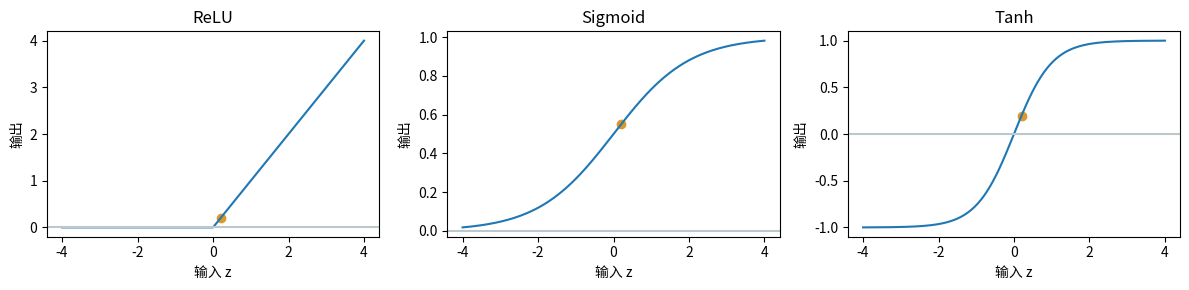

加权求和 z= 0.19999999999999998


In [2]:
X1,X2=.6,.2
W1,W2,BIAS=.5,-1.,.1
z=X1*W1+X2*W2+BIAS
xs=torch.linspace(-4,4,201)
fig,axes=plt.subplots(1,3,figsize=(12,3))
for ax,fn,name in zip(axes,[F.relu,torch.sigmoid,torch.tanh],['ReLU','Sigmoid','Tanh']):
    ax.plot(xs,fn(xs));ax.scatter([z],[fn(torch.tensor(z))],color='#dd982b');ax.axhline(0,color='#bbc8cc');ax.set(title=name,xlabel='输入 z',ylabel='输出')
plt.tight_layout();plt.show();print('加权求和 z=',z)

## 卷积的一个窗口

1 到 25 按五行五列构成一张人工数字图。3×3 全一卷积核每次把窗口里的九个数相加。改动窗口位置，再对照程序算出的输出网格。

窗口: tensor([[ 1.,  2.,  3.],
        [ 6.,  7.,  8.],
        [11., 12., 13.]]) 手算求和: 63.0 输出同位置: 63.0


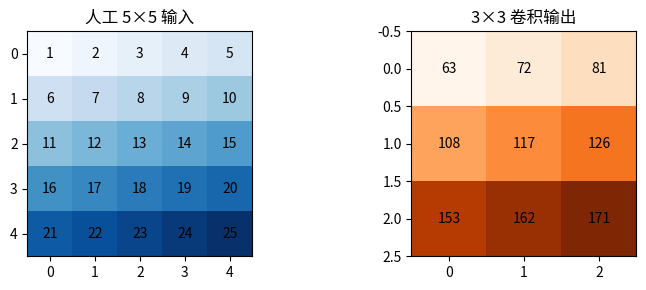

In [3]:
grid=torch.arange(1,26,dtype=torch.float32).reshape(1,1,5,5)
kernel=torch.ones(1,1,3,3)
result=F.conv2d(grid,kernel)
ROW,COL=0,0  # 可取 0、1、2
window=grid[0,0,ROW:ROW+3,COL:COL+3]
print('窗口:',window,'手算求和:',window.sum().item(),'输出同位置:',result[0,0,ROW,COL].item())
fig,axes=plt.subplots(1,2,figsize=(8,3));axes[0].imshow(grid[0,0],cmap='Blues');axes[1].imshow(result[0,0],cmap='Oranges')
for ax,a in zip(axes,[grid[0,0],result[0,0]]):
    for r in range(a.shape[0]):
        for col in range(a.shape[1]):ax.text(col,r,int(a[r,col]),ha='center',va='center')
axes[0].set_title('人工 5×5 输入');axes[1].set_title('3×3 卷积输出');plt.tight_layout();plt.show()

## 池化与分数转换

池化汇总 2×2 网格；分类分数则可以转换为概率。两步使用的对象不同：池化处理空间网格，Softmax 处理同一张照片的类别分数。

最大池化: 4.0 平均池化: 2.5
Softmax: tensor([[0.2689, 0.7311]]) 交叉熵（真实为狗）: 0.31326165795326233


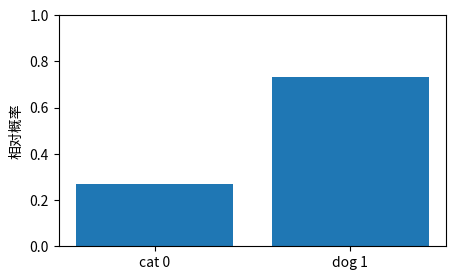

In [4]:
tile=torch.tensor([[[[1.,3.],[2.,4.]]]])
print('最大池化:',F.max_pool2d(tile,2).item(),'平均池化:',F.avg_pool2d(tile,2).item())
LOGITS=torch.tensor([[1.,2.]])  # 可改变两项原始分数
prob=LOGITS.softmax(1)
print('Softmax:',prob,'交叉熵（真实为狗）:',F.cross_entropy(LOGITS,torch.tensor([1])).item())
plt.figure(figsize=(5,3));plt.bar(['cat 0','dog 1'],prob[0]);plt.ylim(0,1);plt.ylabel('相对概率');plt.show()

## 沿梯度更新一个参数

损失 L=(w−3)² 有一个明确最低点。改动学习率，观察一步更新的位置；太大的步长可能越过最低点，甚至使损失增加。

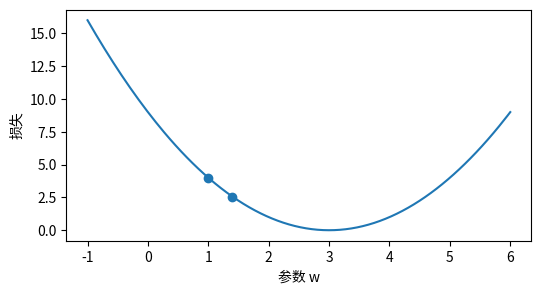

w: 1.0 梯度: -4.0 更新后: 1.4 损失: 2.5600000000000005


In [5]:
W,LR=1.,.1  # 改动 LR，再核对更新位置和损失
gradient=2*(W-3)
updated=W-LR*gradient
x=np.linspace(-1,6,150)
plt.figure(figsize=(6,3));plt.plot(x,(x-3)**2);plt.scatter([W,updated],[(W-3)**2,(updated-3)**2]);plt.xlabel('参数 w');plt.ylabel('损失');plt.show()
print('w:',W,'梯度:',gradient,'更新后:',updated,'损失:',(updated-3)**2)

## Dataset 与 DataLoader

上方四张照片各有一个标签。Dataset 负责按编号取出这一对对象，DataLoader 再把它们组成一批。

In [6]:
from torch.utils.data import Dataset, DataLoader

class PetExamples(Dataset):
    def __init__(self, records):
        self.records = records  # 保存照片与标注的对应记录
    def __len__(self):
        return len(self.records)
    def __getitem__(self, index):
        item = self.records[index]
        image = photo('pets/' + item['image'])  # 一张 [3,64,64] 图像
        label = item['species'] - 1  # 官方 1/2 对应猫 0、狗 1
        return image, label

dataset = PetExamples(samples)
loader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0)
images, labels = next(iter(loader))  # 只取一批；此处没有完整训练循环
print('images:', images.shape, '| labels:', labels.tolist())
assert labels.dtype == torch.long

images: torch.Size([4, 3, 64, 64]) | labels: [0, 0, 1, 1]


## 小批量与未训练模型

照片已经组成批量。一个还未训练的小网络会输出中间张量与最后两项分数；此时这些分数只用于认识计算。

In [7]:
model = nn.Sequential(
    nn.Conv2d(3, 8, kernel_size=3, padding=1),  # 学习局部颜色与纹理计算
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(8, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d(1),  # 每个特征通道汇总为一个数
    nn.Flatten(),
    nn.Linear(16, 2),  # 两个原始类别分数
)

In [8]:
initial_classifier = deepcopy(model)  # 保留未更新参数，后面的单步比较从它重新开始
with torch.no_grad():  # 此格只观察分数，不保留训练计算关系
    logits = model(images)
    probabilities = logits.softmax(dim=1)
print('logits shape:', logits.shape)
print(probabilities)
assert logits.shape == (len(labels),2)
assert torch.allclose(probabilities.sum(dim=1),torch.ones(len(labels)),atol=1e-6)


logits shape: torch.Size([4, 2])
tensor([[0.4642, 0.5358],
        [0.4640, 0.5360],
        [0.4656, 0.5344],
        [0.4674, 0.5326]])


### 输入照片与中间特征

卷积会把三种颜色变成多层特征。下面显示同一张真实照片和第一个卷积层的前三个特征通道，色标按各层数值显示。当前网络还未训练，我们只观察计算产生的空间网格，不把其中一层命名为“耳朵检测器”。

输入的 3 个通道是 RGB，卷积输出的 8 个通道是不同权重产生的空间响应。以下权重尚未训练，各通道没有固定的动物部位含义。

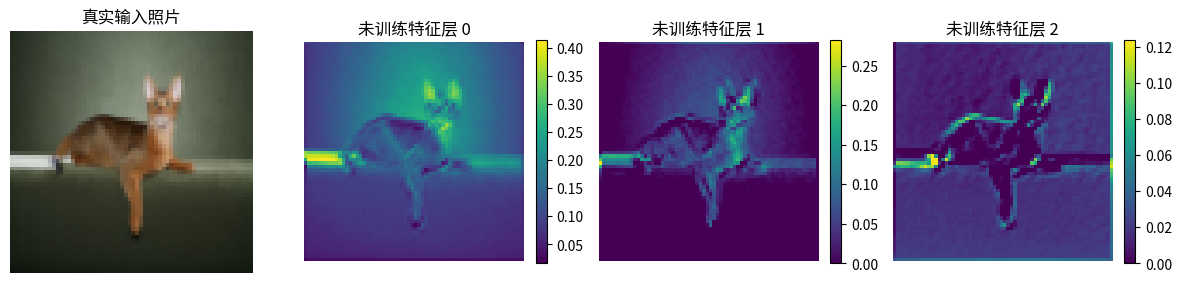

输入: [1, 3, 64, 64] 第一层特征: [1, 8, 64, 64]


In [9]:
with torch.no_grad():
    features = model[1](model[0](images[:1]))  # 第一层卷积和 ReLU 的实际输出
fig, axes = plt.subplots(1,4,figsize=(12,3))
axes[0].imshow(images[0].permute(1,2,0));axes[0].set_title('真实输入照片');axes[0].axis('off')
for channel,ax in enumerate(axes[1:]):
    im=ax.imshow(features[0,channel],cmap='viridis');ax.set_title(f'未训练特征层 {channel}');ax.axis('off');fig.colorbar(im,ax=ax,fraction=.046)
plt.tight_layout();plt.show()
print('输入:',list(images[:1].shape),'第一层特征:',list(features.shape))

## 损失与梯度

这一格恢复同一组初始参数，重新计算分数与损失，再得到梯度。可以反复运行，不会沿用已经释放的计算关系。下一格从这里的模型副本出发，完整执行一次更新。

In [10]:
gradient_model = deepcopy(initial_classifier)  # 每次恢复相同参数，便于重复比较
gradient_model.zero_grad()
fresh_logits = gradient_model(images)  # 本格重新前向计算
loss = F.cross_entropy(fresh_logits, labels)
loss.backward()
print('loss:', loss.item())
print('first convolution gradient norm:', gradient_model[0].weight.grad.norm().item())
assert torch.isfinite(gradient_model[0].weight.grad).all()


loss: 0.6980218887329102
first convolution gradient norm: 0.026828419417142868


In [11]:
updated_model = deepcopy(gradient_model)  # 每次从上一格的参数重新开始
optimizer = torch.optim.SGD(updated_model.parameters(), lr=0.05)
before = updated_model[0].weight.detach().clone()
optimizer.zero_grad()
update_loss = F.cross_entropy(updated_model(images), labels)
update_loss.backward()
optimizer.step()
change = (updated_model[0].weight.detach()-before).abs().mean()
print('mean parameter change:', change.item())
assert change > 0


mean parameter change: 5.255208816379309e-05


## 小练习：学习率与更新量

同样的照片、标签和初始参数，如果只改学习率，更新量会怎样改变？下面从同一状态开始比较，然后把两个学习率改成相同值核对。

In [12]:
LEARNING_RATES = [0.01, 0.1]
observations = []
for learning_rate in LEARNING_RATES:
    candidate = deepcopy(initial_classifier)  # 每次恢复同一组参数，不沿用上一次更新结果
    optimizer = torch.optim.SGD(candidate.parameters(), lr=learning_rate)
    before = candidate[0].weight.detach().clone()
    optimizer.zero_grad()
    loss = F.cross_entropy(candidate(images), labels)
    loss.backward()
    optimizer.step()  # 每个学习率仅计算一次更新
    change = (candidate[0].weight.detach() - before).abs().mean().item()
    observations.append({'learning_rate': learning_rate, 'initial_loss': loss.item(), 'parameter_change': change})
print(observations)
assert abs(observations[0]['initial_loss'] - observations[1]['initial_loss']) < 1e-7

[{'learning_rate': 0.01, 'initial_loss': 0.6980218887329102, 'parameter_change': 1.0510395441087894e-05}, {'learning_rate': 0.1, 'initial_loss': 0.6980218887329102, 'parameter_change': 0.00010510438005439937}]


## 独立应用
猫狗识别代码实践项目已提供数据划分、网络、训练与评价框架，按每格说明补全指定位置。画一张与你实际实现一致的 PPT 流程图，区分预测支路与标签—损失支路。